In [1]:
import os

import pandas as pd
from tqdm import tqdm

tqdm.pandas()

# 1. Load raw data and convert to training data

In [2]:
import gzip
import json

from tqdm import tqdm

FILE_PATHS = [
    '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/princeton-nlp__SWE-bench_Verified-test/CodeActAgent/Qwen3-Coder-30B-A3B-Instruct_maxiter_100_N_v0.61.0-no-hint-run_1/output.with_completions.jsonl.gz'
]

# More memory efficient for large files
# Initialize lists to store the data
data = []


# Read file line by line
for FILE_PATH in FILE_PATHS:
    with gzip.open(FILE_PATH, 'rb') as f:  # Use 'rb' for gzipped files
        for i, line in tqdm(
            enumerate(f), desc=f'Processing {FILE_PATH.split("/")[-1]}'
        ):
            # Parse only the fields we need
            raw_data = json.loads(line)
            data.append(
                {
                    'resolved': raw_data['report']['resolved'],
                    'messages': raw_data['raw_completions']['messages']
                    if raw_data['raw_completions'] is not None
                    else None,
                    'git_patch': raw_data['test_result'].get('git_patch', ''),
                    'tools': raw_data['raw_completions']['tools']
                    if raw_data['raw_completions'] is not None
                    and 'tools' in raw_data['raw_completions']
                    else None,
                }
            )

# Convert to DataFrame after collecting all data
df = pd.DataFrame(data)
print(f'#total amount of data={len(df)}')
df = df[~df['messages'].isna()]
print(f'#total amount of data after removing nan={len(df)}')

Processing output.with_completions.jsonl.gz: 500it [00:03, 148.05it/s]

#total amount of data=500
#total amount of data after removing nan=500


## Filter

In [3]:
def _contains_multiple_tool_calls(messages: list[dict]) -> bool:
    return any(
        message.get('tool_calls') and len(message['tool_calls']) > 1
        for message in messages
    )


df['contains_multiple_tool_calls'] = df['messages'].apply(_contains_multiple_tool_calls)
display(df.groupby(['contains_multiple_tool_calls'])['resolved'].sum())

contains_multiple_tool_calls
False    222
Name: resolved, dtype: int64

In [4]:
import copy

# Convert function calling messages to non-function calling messages
from openhands.llm.fn_call_converter import (
    FunctionCallConversionError,
    convert_fncall_messages_to_non_fncall_messages,
    convert_from_multiple_tool_calls_to_single_tool_call_messages,
)

total_failed = 0


def _convert_messages(messages: list[dict], tools: list[dict]) -> list[dict]:
    global total_failed
    message_copy = copy.deepcopy(messages)
    for message in message_copy:
        if message['content'] is None:
            message['content'] = ''
    try:
        return convert_fncall_messages_to_non_fncall_messages(
            message_copy, tools, add_in_context_learning_example=False
        )
    except FunctionCallConversionError:
        total_failed += 1
        # print(f'Failed to convert messages: {messages}\nTools: {tools}')
        # traceback.print_exc()
        return None


df['converted_messages'] = df.apply(
    lambda row: convert_from_multiple_tool_calls_to_single_tool_call_messages(
        row['messages'], ignore_final_tool_result=True
    ),
    axis=1,
)
df['nonfncall_messages'] = df.apply(
    lambda row: _convert_messages(row['converted_messages'], row['tools']), axis=1
)
print('total nan', df['nonfncall_messages'].isna().sum())
df = df[~df['nonfncall_messages'].isna()]
print(f'Total failed: {total_failed}')

total nan 0
Total failed: 0


In [19]:
def normalize_message_content(messages: list[dict]) -> list[dict]:
    """Convert content from list format to string format for tokenizer compatibility."""
    normalized = []
    for msg in messages:
        msg_copy = msg.copy()
        content = msg_copy.get('content', '')
        
        # If content is a list (like [{'type': 'text', 'text': '...'}])
        if isinstance(content, list):
            # Extract text from all items and concatenate
            text_parts = []
            for item in content:
                if isinstance(item, dict) and item.get('type') == 'text':
                    text_parts.append(item.get('text', ''))
            msg_copy['content'] = '\n'.join(text_parts)
        elif content is None:
            msg_copy['content'] = ''
        
        normalized.append(msg_copy)
    return normalized


# Normalize message content for tokenization
df['normalized_messages'] = df['nonfncall_messages'].apply(normalize_message_content)
print(f'Normalized {len(df)} message sets')


Normalized 500 message sets


In [39]:
# print(df.head())
message = df['nonfncall_messages'].iloc[0]
print(len(message))
item = message[8]
print(item['role'])
print(item['content'])

101
assistant
[{'type': 'text', 'text': '<function=str_replace_editor>\n<parameter=path>/workspace/scikit-learn__scikit-learn__0.21/README.rst</parameter>\n<parameter=command>view</parameter>\n<parameter=security_risk>LOW</parameter>\n<parameter=view_range>[1, 50]</parameter>\n</function>'}]


## Standard Tokenizer Input Format

The tokenizer expects a list of message dictionaries with the following structure:
```python
messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "Hello!"},
    {"role": "assistant", "content": "Hi there!"}
]
```

Key requirements:
- **`role`**: Must be one of: `"system"`, `"user"`, or `"assistant"`
- **`content`**: Must be a **string** (not a list, not None)
- Optional fields like `name`, `tool_calls`, `tool_call_id` may be present but are model-specific

In [ ]:
# Example: Check the format of your data
print("=== Original nonfncall_messages format ===")
sample_msg = df['nonfncall_messages'].iloc[0][0]  # First message of first conversation
print(f"Keys: {sample_msg.keys()}")
print(f"Role: {sample_msg['role']}")
print(f"Content type: {type(sample_msg['content'])}")
if isinstance(sample_msg['content'], list):
    print(f"Content (list): {sample_msg['content'][:1]}")  # Show first item
else:
    print(f"Content (str): {sample_msg['content'][:100]}...")  # Show first 100 chars

print("\n=== Normalized messages format ===")
normalized_msg = df['normalized_messages'].iloc[0][0]
print(f"Keys: {normalized_msg.keys()}")
print(f"Role: {normalized_msg['role']}")
print(f"Content type: {type(normalized_msg['content'])}")
print(f"Content preview: {normalized_msg['content'][:100]}...")

print("\n=== Standard format example ===")
standard_example = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "What is 2+2?"},
    {"role": "assistant", "content": "2+2 equals 4."}
]
print(standard_example)

In [ ]:
# Test tokenizer with normalized messages
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B-Instruct')

print("=== Testing tokenizer ===")
# Test with a single normalized conversation
test_messages = df['normalized_messages'].iloc[0]
try:
    token_ids = tokenizer.apply_chat_template(test_messages)
    print(f"✓ Success! Tokenized {len(test_messages)} messages into {len(token_ids)} tokens")
    print(f"Token count: {len(token_ids)}")
except Exception as e:
    print(f"✗ Error: {e}")

# Show what the chat template produces
print("\n=== Decoded output (first 500 chars) ===")
decoded = tokenizer.decode(token_ids[:500])
print(decoded)

## Tokenization

In [12]:
from pandarallel import pandarallel
from transformers import AutoTokenizer

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
pandarallel.initialize(progress_bar=True, verbose=1, nb_workers=16)
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B-Instruct')
df['n_tokens'] = df['normalized_messages'].parallel_apply(
    lambda x: len(tokenizer.apply_chat_template(x))
)

In [13]:
print(f'BEFORE: #total={len(df)}')
df_selected = df[df['n_tokens'] < 131072]
print(f'AFTER(truncated to 128k): #total={len(df_selected)}')

BEFORE: #total=500
AFTER(truncated to 128k): #total=500


In [14]:
df_selected['n_tokens'].describe()

count       500.000000
mean      50114.152000
std       15924.301109
min       22511.000000
25%       38451.750000
50%       46404.000000
75%       58456.000000
max      129749.000000
Name: n_tokens, dtype: float64

,count,mean,std,min,25%,50%,75%,max
resolved,,,,,,,,
False,278.0,55820.956835,16342.304799,25940.0,43607.00,53937.5,66562.0,129749.0
True,222.0,42967.792793,12064.685079,22511.0,34748.75,40949.0,48231.0,114954.0


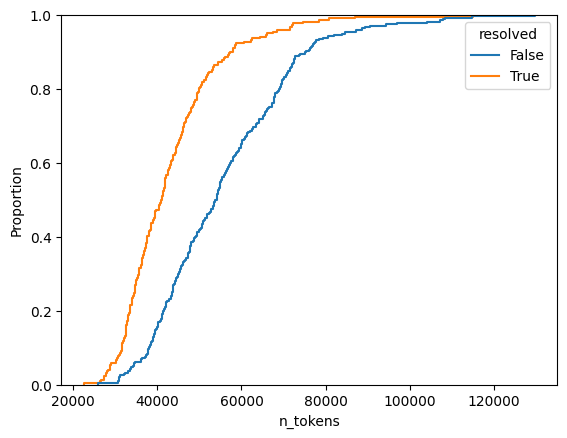

#total=500
#selected=500


,count,mean,std,min,25%,50%,75%,max
resolved,,,,,,,,
False,278.0,55820.956835,16342.304799,25940.0,43607.00,53937.5,66562.0,129749.0
True,222.0,42967.792793,12064.685079,22511.0,34748.75,40949.0,48231.0,114954.0


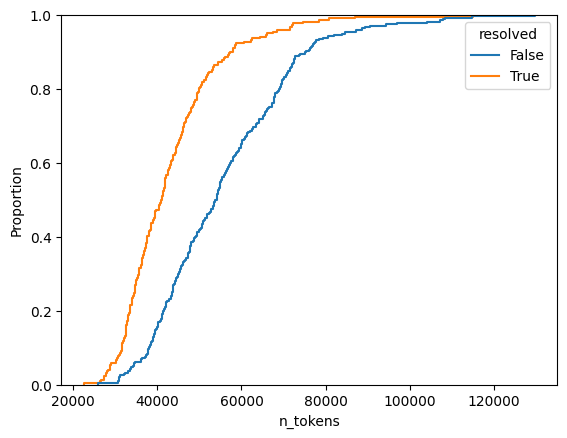

In [15]:
# ecdf of n_tokens
import matplotlib.pyplot as plt
import seaborn as sns

display(df.groupby(['resolved'])['n_tokens'].describe())
sns.ecdfplot(x='n_tokens', data=df, hue='resolved')
plt.show()

print(f'#total={len(df)}')
df_selected = df[df['n_tokens'] < 131072]
print(f'#selected={len(df_selected)}')
display(df_selected.groupby(['resolved'])['n_tokens'].describe())
sns.ecdfplot(x='n_tokens', data=df_selected, hue='resolved')
plt.show()

In [16]:
df_selected[~df_selected['resolved']]['n_tokens'].describe()

count       278.000000
mean      55820.956835
std       16342.304799
min       25940.000000
25%       43607.000000
50%       53937.500000
75%       66562.000000
max      129749.000000
Name: n_tokens, dtype: float64

In [ ]:
df_selected['resolved'].value_counts()

In [ ]:
df_selected.groupby(['resolved'])['n_tokens'].describe()

# Save Resolved Messages for SFT

In [ ]:
df_selected[df_selected['resolved']][['nonfncall_messages']].rename(
    columns={'nonfncall_messages': 'messages'}
).to_json(
    os.path.join(
        'YOUR_OUTPUT_FOLDER',
        f'policy_traj_128k_swegym_{df_selected["resolved"].value_counts()[True]}i.jsonl',
    ),
    lines=True,
    orient='records',
)